# Import Libraries

In [12]:
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [13]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_final.csv'
)

In [14]:
womens_world_cup_stats

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,3904629,2023-08-16,England Women's,Australia Women's,Semi-finals,3,1,W,3,49.971523,...,1.0,1,19,12.0,7,16,30,51,3,0
124,3906389,2023-08-19,Australia Women's,Sweden Women's,Third-place,0,2,L,0,52.821967,...,0.0,0,18,11.0,17,27,9,66,3,0
125,3906389,2023-08-19,Sweden Women's,Australia Women's,Third-place,2,0,W,3,47.178033,...,1.0,0,26,16.0,12,31,29,65,4,1
126,3906390,2023-08-20,England Women's,Spain Women's,Final,0,1,L,0,44.284665,...,0.0,0,25,13.0,7,24,18,54,4,0


# Filter the Group Stage

In [16]:
group_stage = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Group'
]

In [17]:
group_stage

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,3893832,2023-08-02,Jamaica Women's,Brazil Women's,Group,0,0,D,1,29.464669,...,0.0,0,22,12.0,13,30,46,67,8,1
92,3893833,2023-08-03,Germany Women's,Korea Republic Women's,Group,1,1,D,1,60.364924,...,0.0,0,16,10.0,14,14,32,64,1,0
93,3893833,2023-08-03,Korea Republic Women's,Germany Women's,Group,1,1,D,1,39.635076,...,0.0,0,25,12.0,10,28,26,64,2,0
94,3893834,2023-08-03,Colombia Women's,Morocco Women's,Group,0,1,L,0,58.744898,...,0.0,0,28,13.0,22,28,18,81,5,0


In [18]:
teams = womens_world_cup_stats["team"].unique()

list(teams)

["New Zealand Women's",
 "Norway Women's",
 "Australia Women's",
 "Republic of Ireland Women's",
 "Philippines Women's",
 "Switzerland Women's",
 "Canada Women's",
 "Nigeria Women's",
 "Costa Rica Women's",
 "Spain Women's",
 "United States Women's",
 "Vietnam Women's",
 "Japan Women's",
 'Zambia W',
 "England Women's",
 "Haiti Women's",
 "China PR Women's",
 "Denmark Women's",
 "South Africa Women's",
 "Sweden Women's",
 "Netherlands Women's",
 "Portugal Women's",
 "France Women's",
 "Jamaica Women's",
 "Germany Women's",
 "Morocco Women's",
 "Argentina Women's",
 "Italy Women's",
 "Brazil Women's",
 "Panama Women's",
 "Colombia Women's",
 "Korea Republic Women's"]

# Analysis Netherlands's Group Stage games

In [20]:
team = "Netherlands Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
20,3893797,Netherlands Women's,Portugal Women's,Group
21,3893797,Portugal Women's,Netherlands Women's,Group
42,3893808,Netherlands Women's,United States Women's,Group
43,3893808,United States Women's,Netherlands Women's,Group
80,3893827,Netherlands Women's,Vietnam Women's,Group
81,3893827,Vietnam Women's,Netherlands Women's,Group


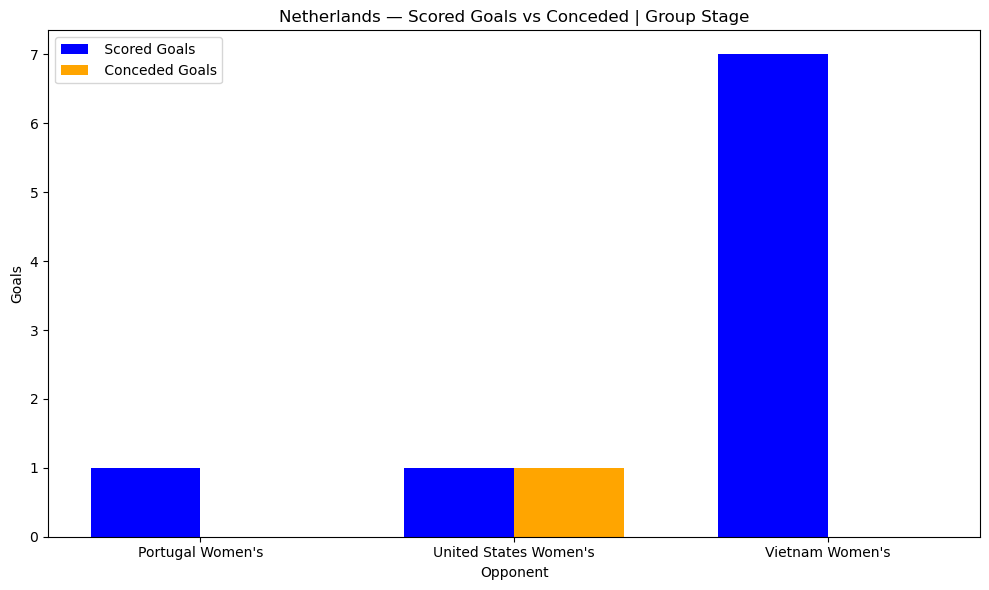

In [21]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Netherlands Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Netherlands — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

The Netherlands won two games in the group stage and tied one (against the United States).

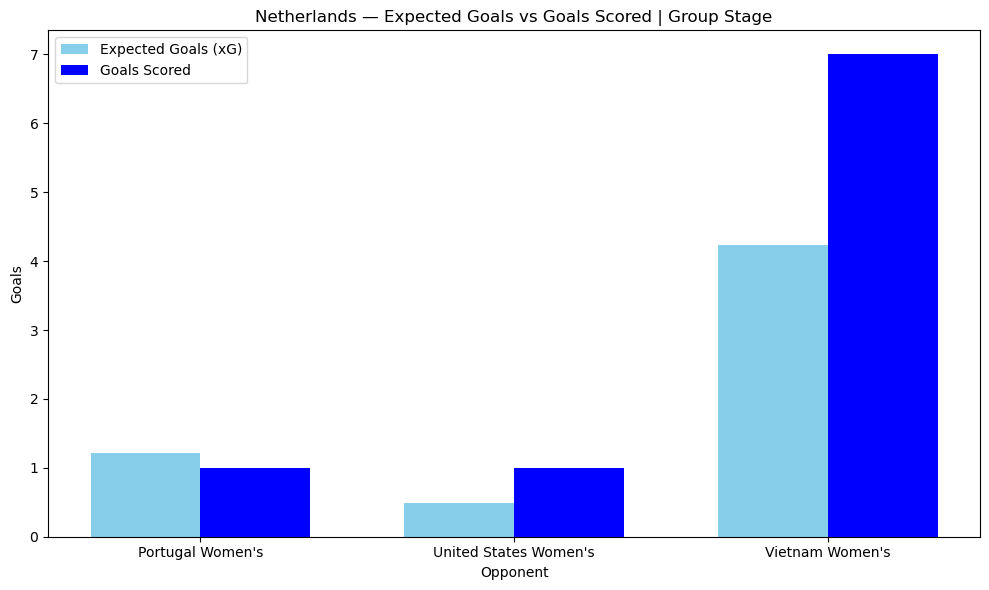

In [23]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Netherlands Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Netherlands — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

According to the charts above, the Netherlands outperformed expectations, except when compared to Portugal.

# Analysis NED-USA

In [26]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Netherlands Women's") &
        (womens_world_cup_stats["opponent"] == "United States Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "United States Women's") &
        (womens_world_cup_stats["opponent"] == "Netherlands Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Netherlands": [
        match.loc[
            match["team"] == "Netherlands Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "USA": [
        match.loc[
            match["team"] == "United States Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Netherlands", "USA"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Netherlands", "USA"]
].round(1)


# Display table

comparison

,Metric,Netherlands,USA
0,Goals,1.0,1.0
1,xG,0.5,1.0
2,Goals Minus xG,0.5,-0.0
3,Shots,5.0,18.0
4,Shots on Target,1.0,3.0
5,Saves,2.0,0.0
6,Possession %,47.8,52.2
7,Pass Accuracy %,78.9,68.0
8,Progressive Passes,127.0,109.0
9,Progressive Carries,24.0,20.0


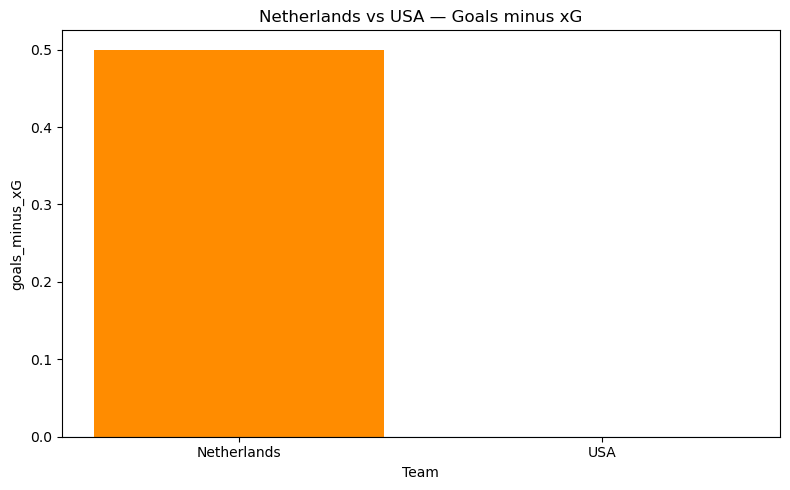

In [119]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Netherlands Women's") &
        (womens_world_cup_stats["opponent"] == "United States Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "United States Women's") &
        (womens_world_cup_stats["opponent"] == "Netherlands Women's")
    )
].copy()


teams = ["Netherlands", "USA"]

goals_minus_xG = [
    match.loc[match["team"] == "Netherlands Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "United States Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["darkorange", "blue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Netherlands vs USA — Goals minus xG")

plt.tight_layout()
plt.show()

The Netherlands performed slightly better than expected in terms of xG, while the U.S. performed exactly as predicted.

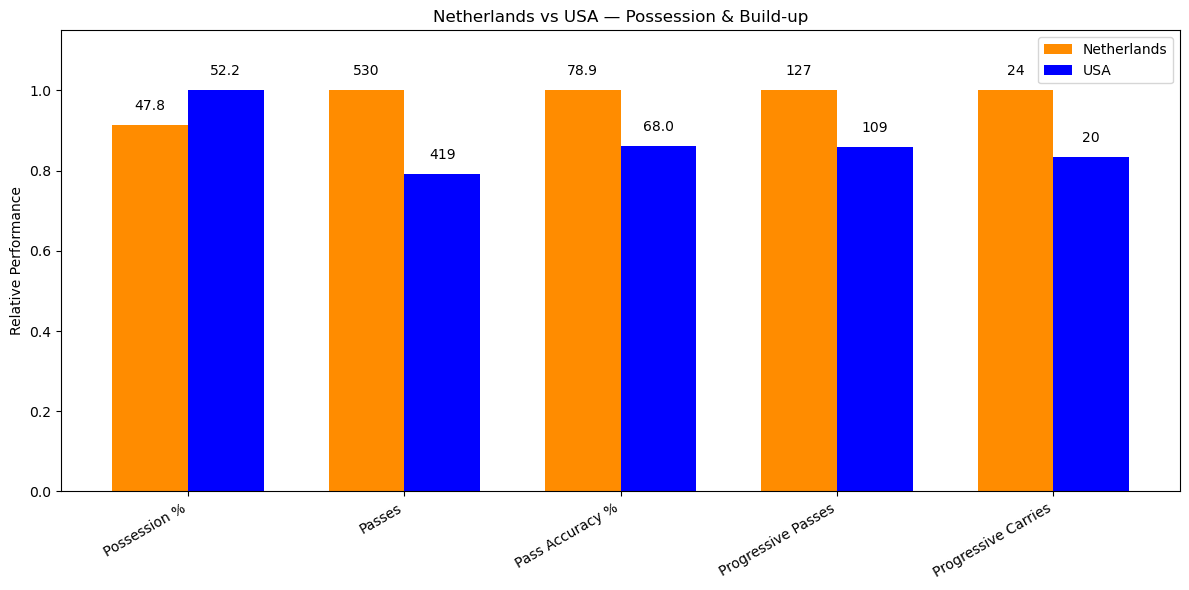

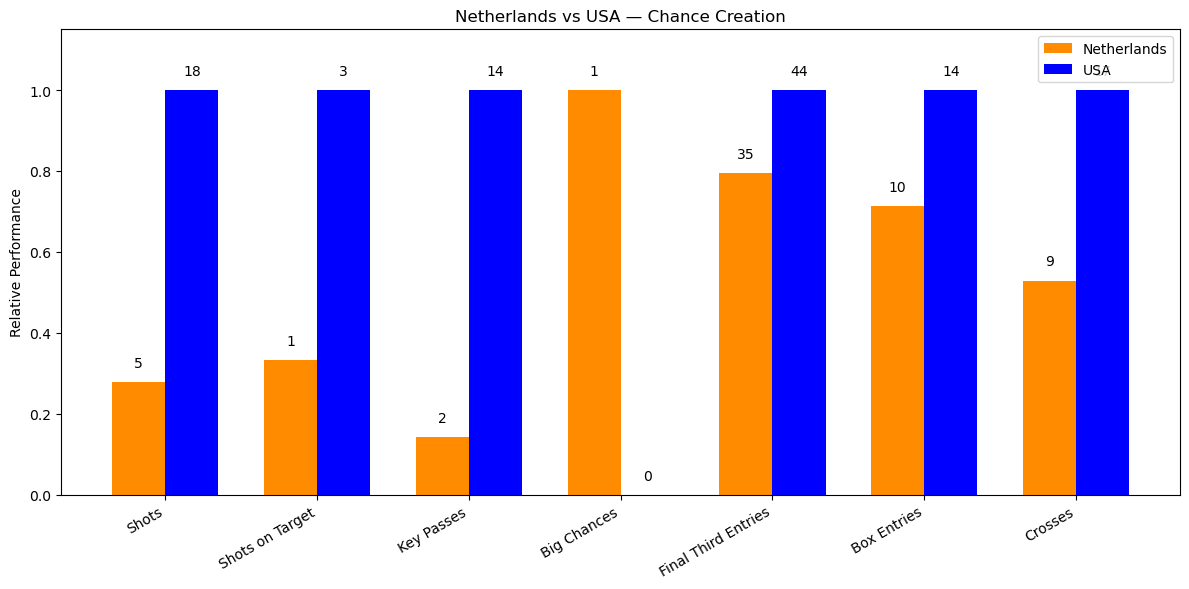

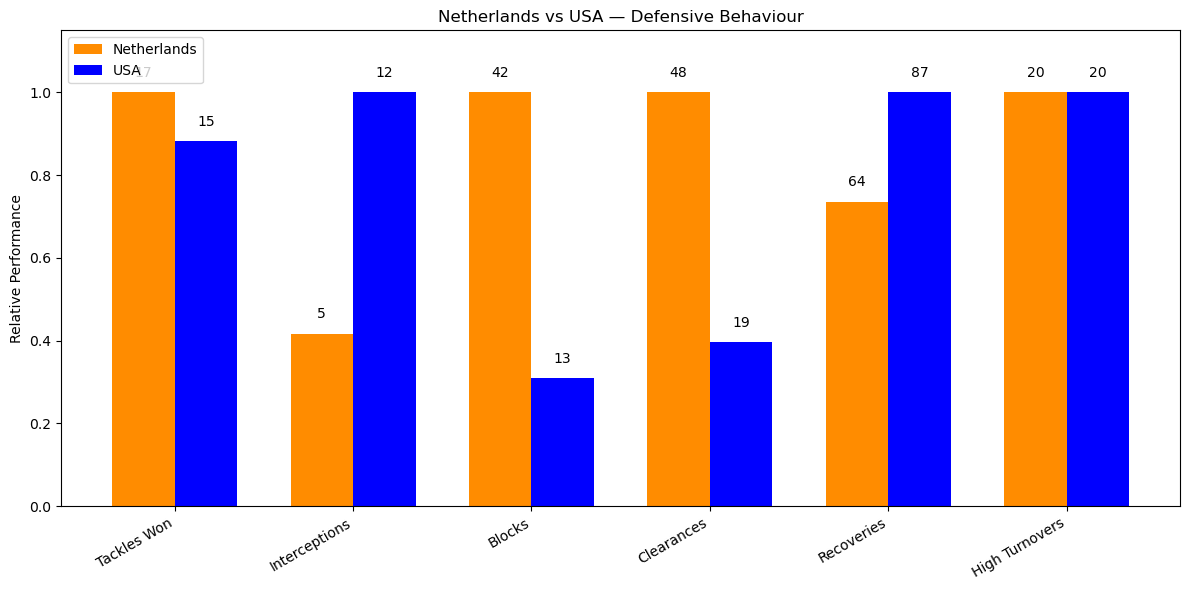

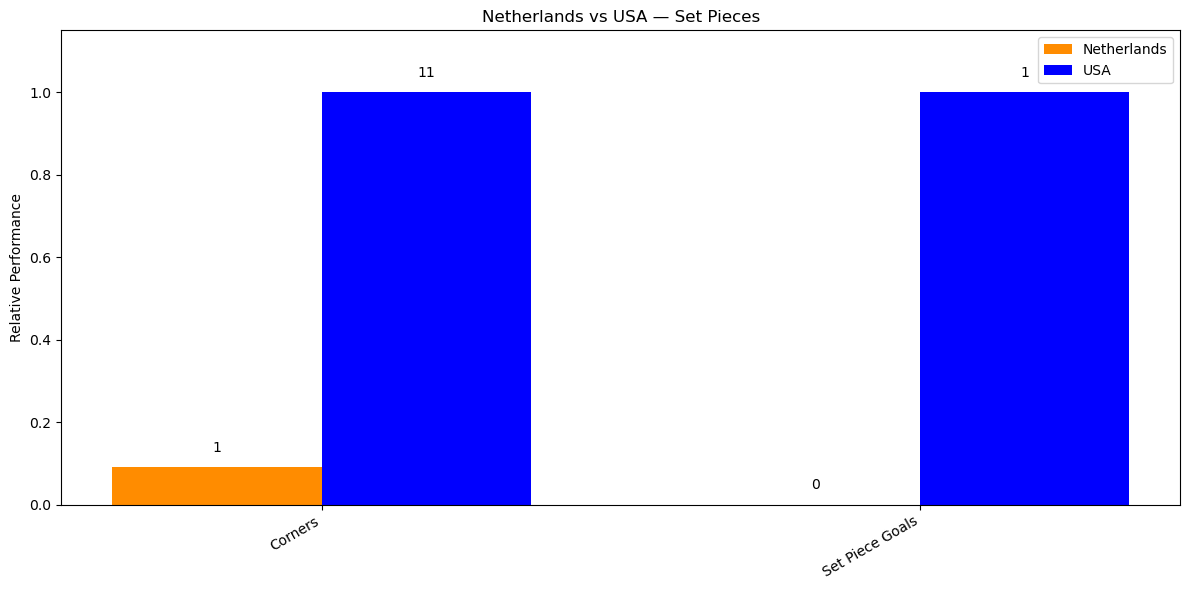

In [29]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Netherlands Women's") &
        (womens_world_cup_stats["opponent"] == "United States Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "United States Women's") &
        (womens_world_cup_stats["opponent"] == "Netherlands Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Netherlands": "Netherlands Women's",
    "USA": "United States Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    ned_values = np.array([
        match.loc[
            match["team"] == team_names["Netherlands"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    usa_values = np.array([
        match.loc[
            match["team"] == team_names["USA"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(ned_values, usa_values)

    # Normalize
    ned_normalized = np.divide(
        ned_values,
        max_values,
        out=np.zeros_like(ned_values),
        where=max_values != 0
    )

    usa_normalized = np.divide(
        usa_values,
        max_values,
        out=np.zeros_like(usa_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_ned = plt.bar(
        x - width / 2,
        ned_normalized,
        width,
        label="Netherlands",
        color="darkorange"
    )

    bars_usa = plt.bar(
        x + width / 2,
        usa_normalized,
        width,
        label="USA",
        color="blue"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_ned, ned_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_usa, usa_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Netherlands vs USA — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion NED-USA

In this game, I think the United States created quite a few opportunities—and at first glance, it might seem like they dominated the game for almost the entire time. But after analyzing the statistics, I noticed that the Netherlands was much more productive and efficient with the opportunities it had.
The U.S. numbers are, in a way, scattered and suggest a lack of consistency and finishing ability. 

# Analysis NED-PT

In [33]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Netherlands Women's") &
        (womens_world_cup_stats["opponent"] == "Portugal Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Portugal Women's") &
        (womens_world_cup_stats["opponent"] == "Netherlands Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Netherlands": [
        match.loc[
            match["team"] == "Netherlands Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Portugal": [
        match.loc[
            match["team"] == "Portugal Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Netherlands", "Portugal"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Netherlands", "Portugal"]
].round(1)


# Display table

comparison

,Metric,Netherlands,Portugal
0,Goals,1.0,0.0
1,xG,1.2,0.1
2,Goals Minus xG,-0.2,-0.1
3,Shots,12.0,2.0
4,Shots on Target,5.0,1.0
5,Saves,1.0,4.0
6,Possession %,55.2,44.8
7,Pass Accuracy %,75.9,66.9
8,Progressive Passes,103.0,78.0
9,Progressive Carries,22.0,10.0


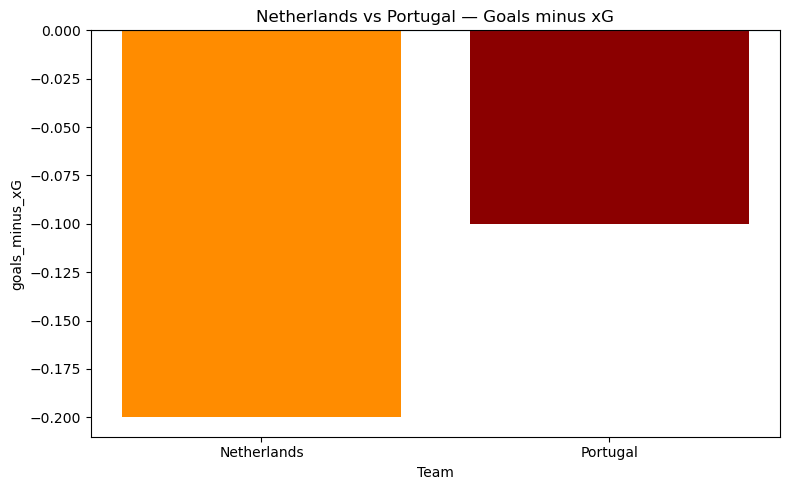

In [34]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Netherlands Women's") &
        (womens_world_cup_stats["opponent"] == "Portugal Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Portugal Women's") &
        (womens_world_cup_stats["opponent"] == "Netherlands Women's")
    )
].copy()


teams = ["Netherlands", "Portugal"]

goals_minus_xG = [
    match.loc[match["team"] == "Netherlands Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Portugal Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["darkorange", "darkred"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Netherlands vs Portugal — Goals minus xG")

plt.tight_layout()
plt.show()

Both teams fell short of expectations based on xG. 

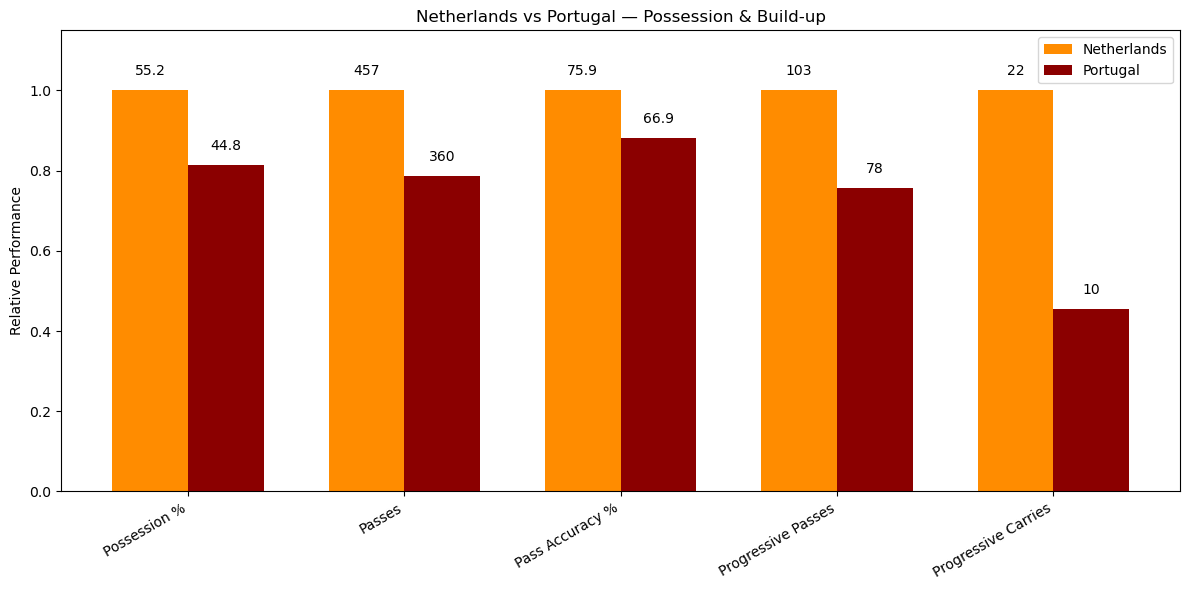

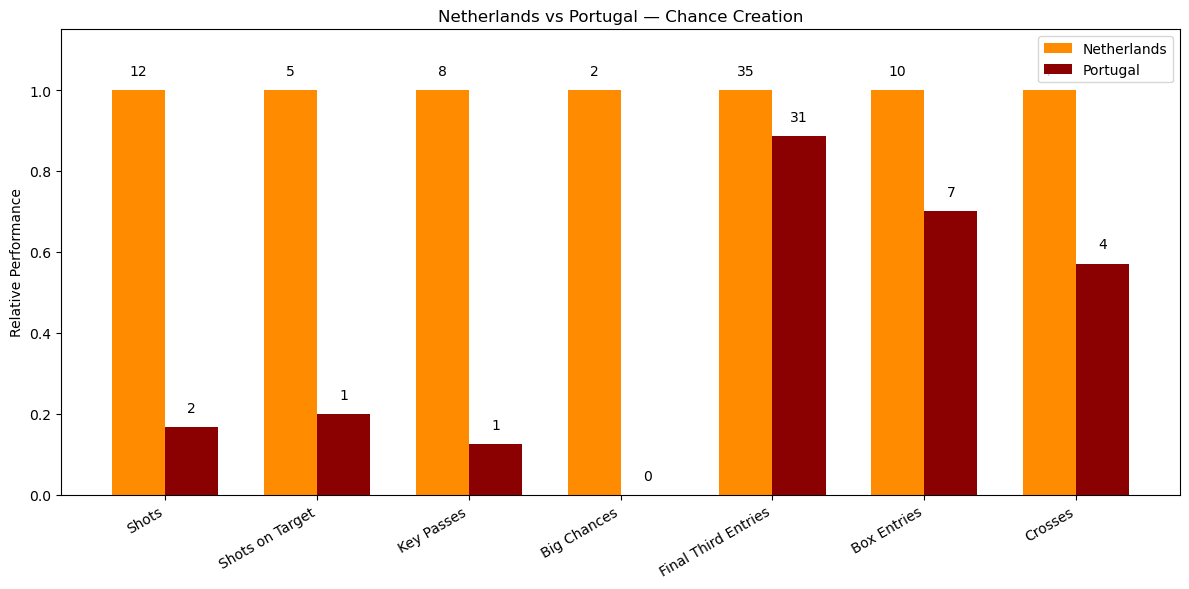

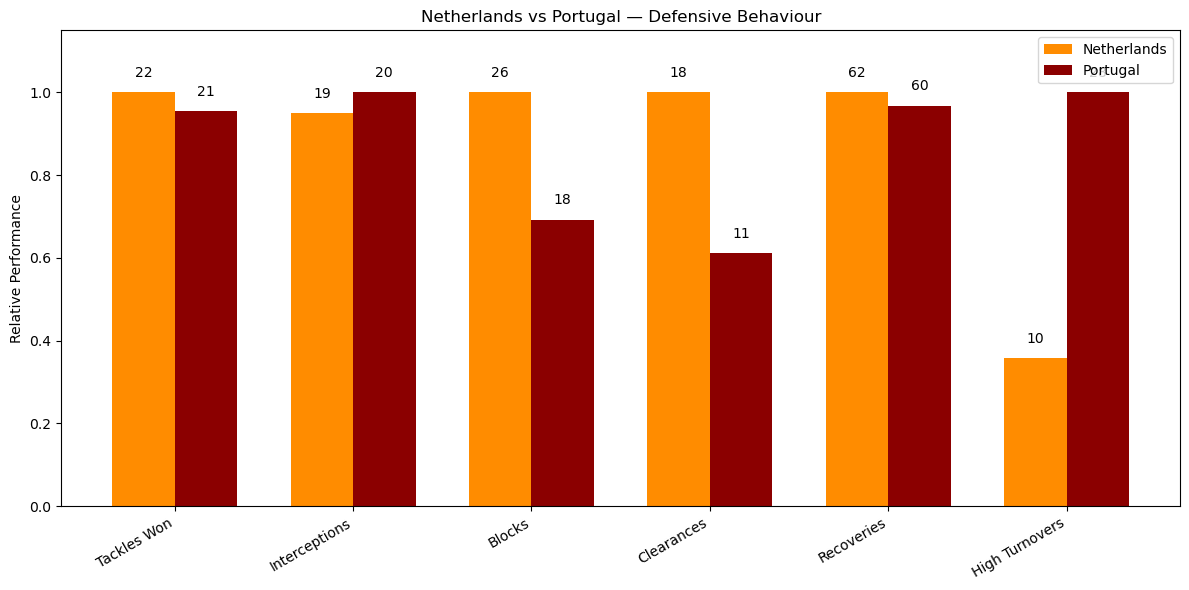

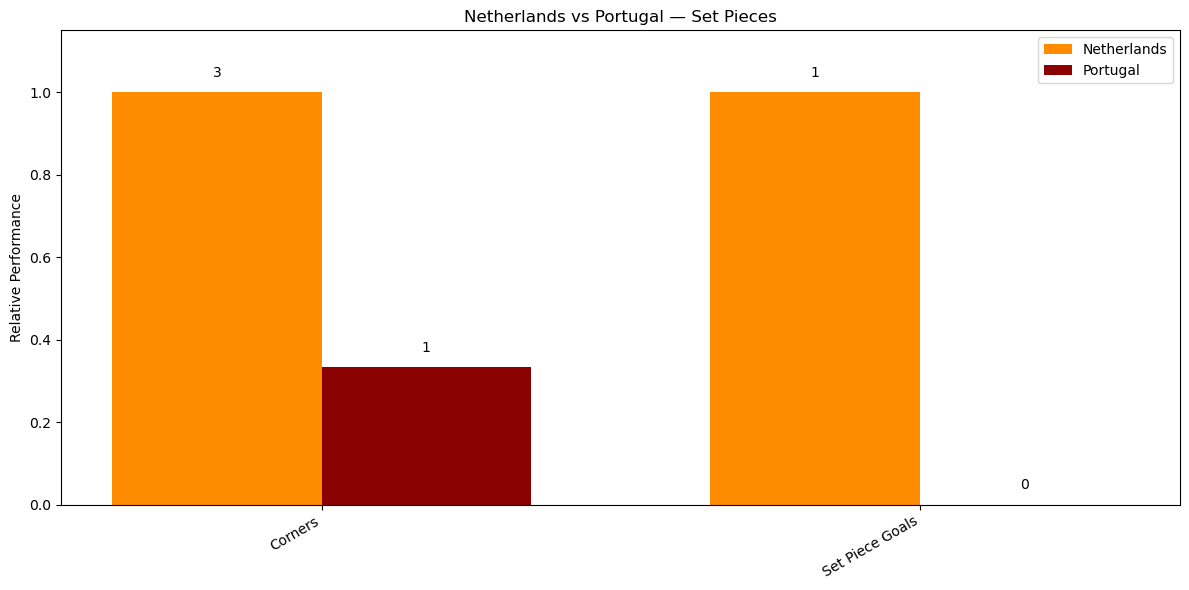

In [36]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Netherlands Women's") &
        (womens_world_cup_stats["opponent"] == "Portugal Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Portugal Women's") &
        (womens_world_cup_stats["opponent"] == "Netherlands Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Netherlands": "Netherlands Women's",
    "Portugal": "Portugal Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    ned_values = np.array([
        match.loc[
            match["team"] == team_names["Netherlands"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    por_values = np.array([
        match.loc[
            match["team"] == team_names["Portugal"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(ned_values, por_values)

    # Normalize
    ned_normalized = np.divide(
        ned_values,
        max_values,
        out=np.zeros_like(ned_values),
        where=max_values != 0
    )

    por_normalized = np.divide(
        por_values,
        max_values,
        out=np.zeros_like(por_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_ned = plt.bar(
        x - width / 2,
        ned_normalized,
        width,
        label="Netherlands",
        color="darkorange"
    )

    bars_por = plt.bar(
        x + width / 2,
        por_normalized,
        width,
        label="Portugal",
        color="darkred"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_ned, ned_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_por, por_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Netherlands vs Portugal — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion NED-POR 

The charts above highlight a very uneven match. The Netherlands had more possession and dominated the game more than Portugal. However, on defense, Portugal held its own against the opponent.
Although the numbers show the dominance of the Dutch team, Portugal was also able to keep pace with its opponent.

# Analysis NED-VIE

In [40]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Netherlands Women's") &
        (womens_world_cup_stats["opponent"] == "Vietnam Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Vietnam Women's") &
        (womens_world_cup_stats["opponent"] == "Netherlands Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Netherlands": [
        match.loc[
            match["team"] == "Netherlands Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Vietnam": [
        match.loc[
            match["team"] == "Vietnam Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Netherlands", "Vietnam"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Netherlands", "Vietnam"]
].round(1)


# Display table

comparison

,Metric,Netherlands,Vietnam
0,Goals,7.0,0.0
1,xG,4.2,0.3
2,Goals Minus xG,2.8,-0.3
3,Shots,41.0,5.0
4,Shots on Target,17.0,1.0
5,Saves,1.0,10.0
6,Possession %,73.2,26.8
7,Pass Accuracy %,87.1,62.9
8,Progressive Passes,169.0,90.0
9,Progressive Carries,46.0,12.0


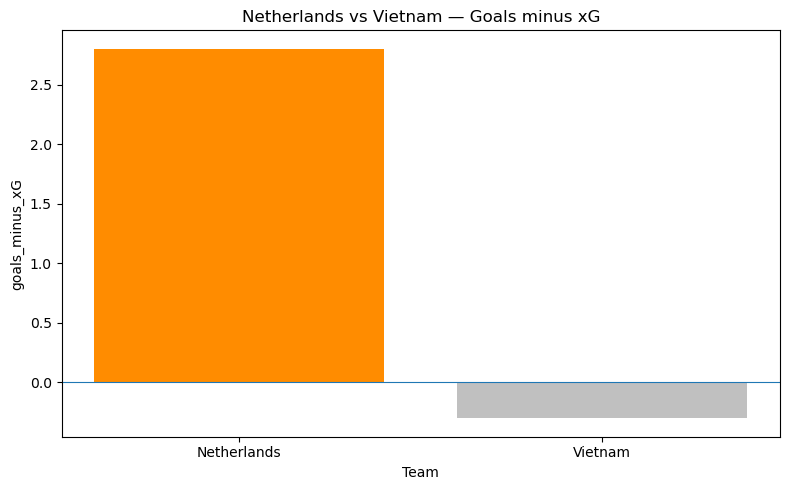

In [41]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Netherlands Women's") &
        (womens_world_cup_stats["opponent"] == "Vietnam Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Vietnam Women's") &
        (womens_world_cup_stats["opponent"] == "Netherlands Women's")
    )
].copy()


teams = ["Netherlands", "Vietnam"]

goals_minus_xG = [
    match.loc[match["team"] == "Netherlands Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Vietnam Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["darkorange", "silver"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Netherlands vs Vietnam — Goals minus xG")

plt.tight_layout()
plt.show()

The Netherlands performed well above expectations, while Vietnam, unfortunately, performed below expectations.

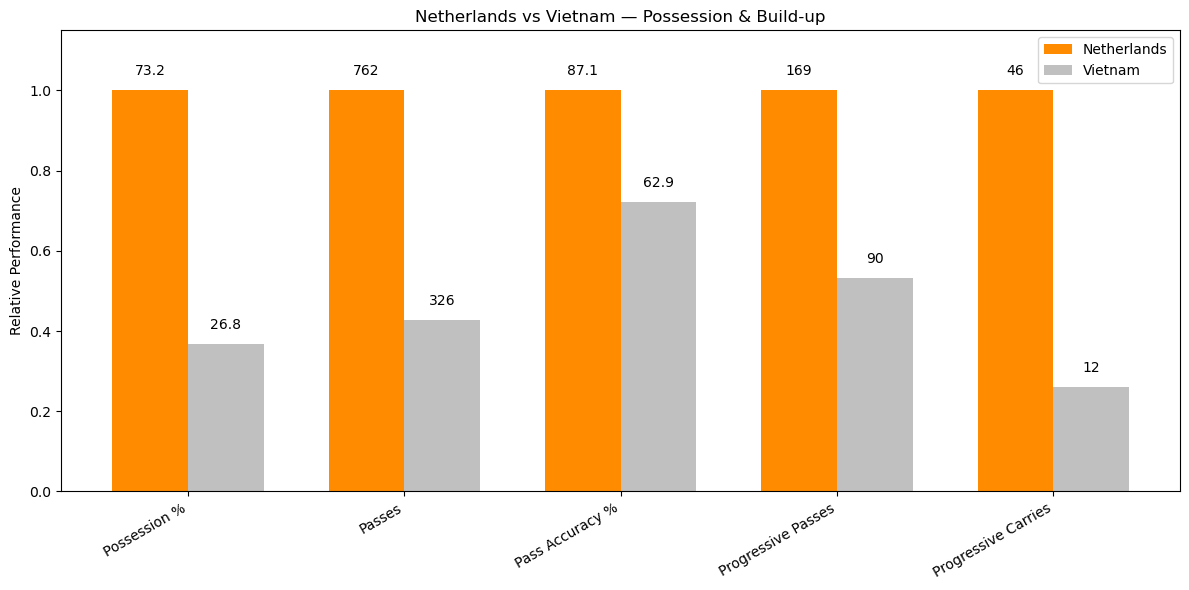

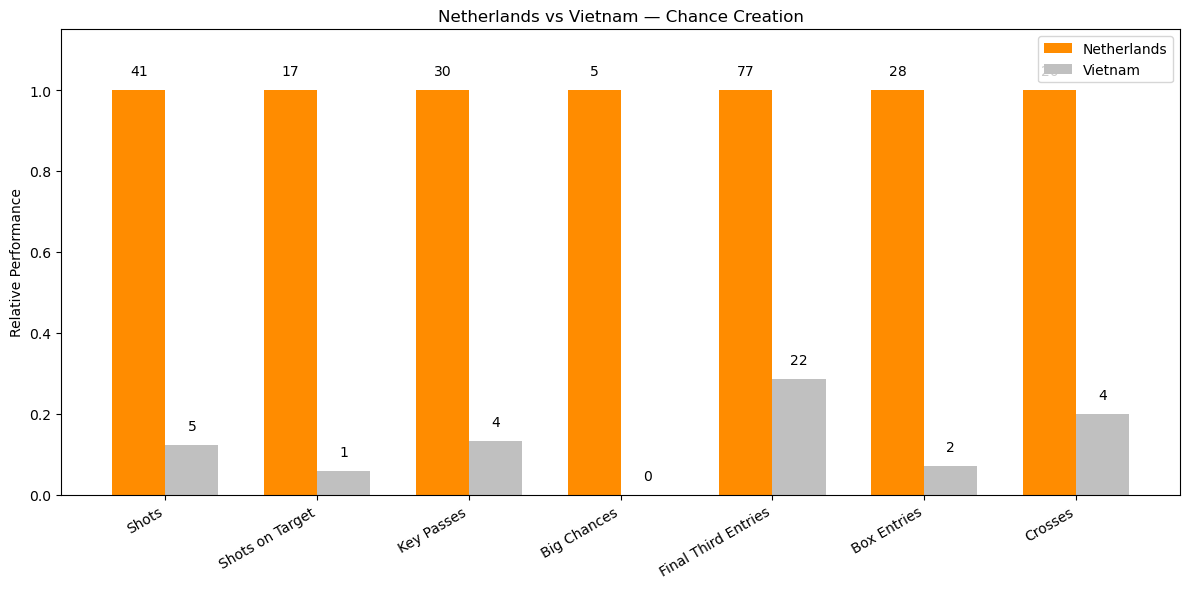

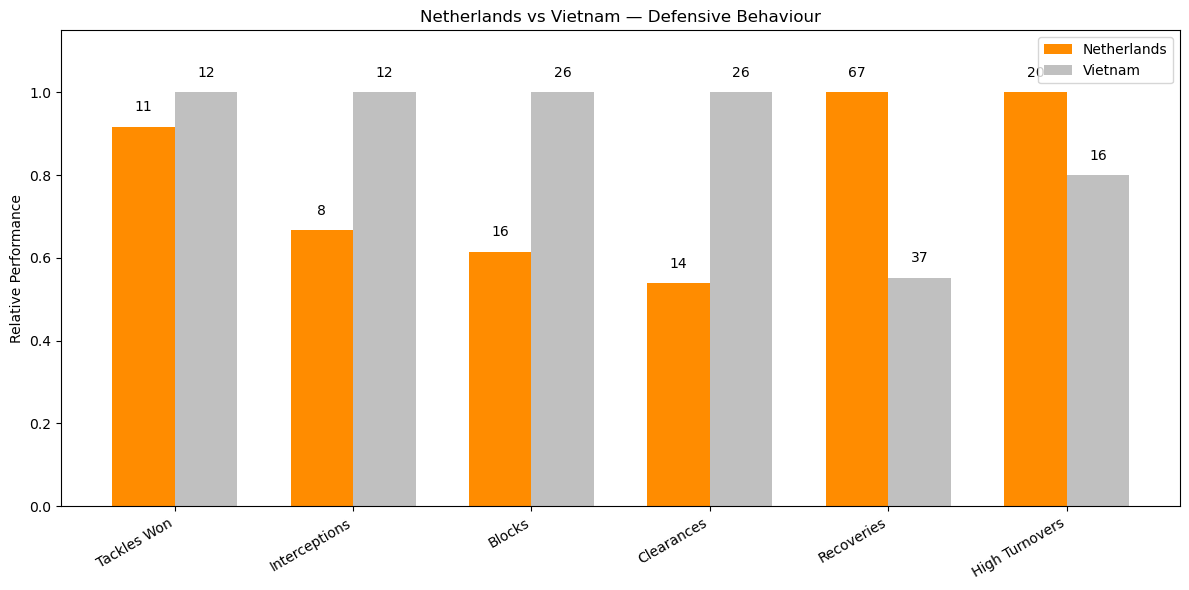

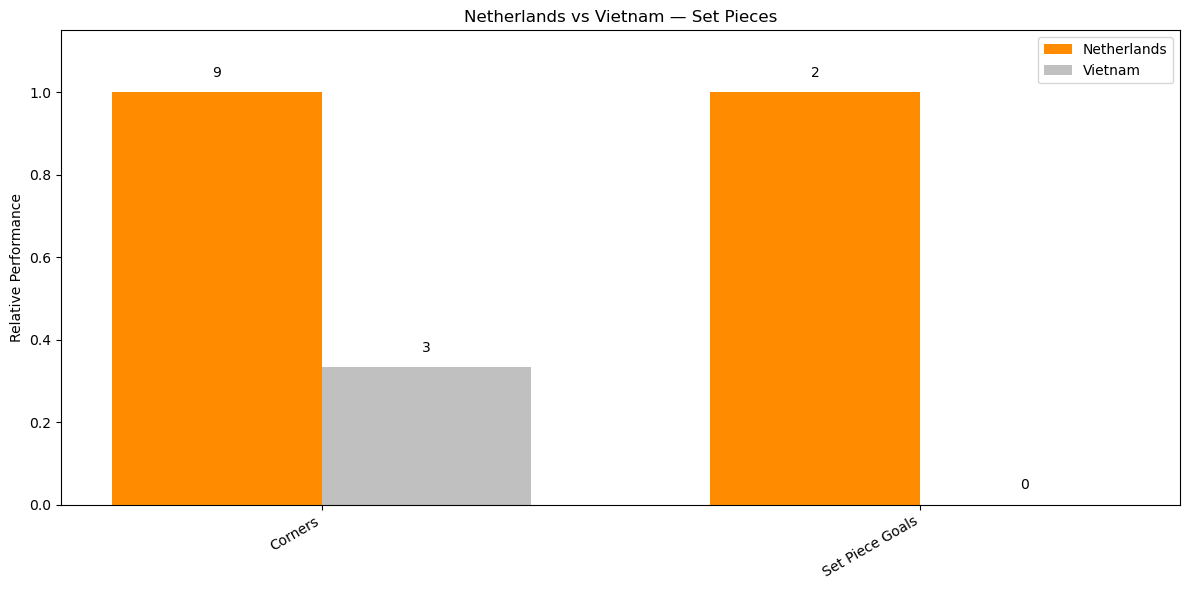

In [43]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Netherlands Women's") &
        (womens_world_cup_stats["opponent"] == "Vietnam Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Vietnam Women's") &
        (womens_world_cup_stats["opponent"] == "Netherlands Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Netherlands": "Netherlands Women's",
    "Vietnam": "Vietnam Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    ned_values = np.array([
        match.loc[
            match["team"] == team_names["Netherlands"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    vie_values = np.array([
        match.loc[
            match["team"] == team_names["Vietnam"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(ned_values, vie_values)

    # Normalize
    ned_normalized = np.divide(
        ned_values,
        max_values,
        out=np.zeros_like(ned_values),
        where=max_values != 0
    )

    vie_normalized = np.divide(
        vie_values,
        max_values,
        out=np.zeros_like(vie_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_ned = plt.bar(
        x - width / 2,
        ned_normalized,
        width,
        label="Netherlands",
        color="darkorange"
    )

    bars_vie = plt.bar(
        x + width / 2,
        vie_normalized,
        width,
        label="Vietnam",
        color="silver"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_ned, ned_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_vie, vie_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Netherlands vs Vietnam — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion NED-VIE

The Netherlands clearly dominated the game in terms of offensive output, with 45 shots and 17 on target. However, the 7 goals significantly exceeded the quality of the chances created: with just 4.5 xG, the Netherlands scored 2.5 goals more than expected. This suggests particularly effective finishing, though accompanied by some inaccuracy in shooting, as only 17 of the 45 shots were on target.

# Analysis USA's Group Stage games

In [47]:
team = "United States Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
10,3893792,United States Women's,Vietnam Women's,Group
11,3893792,Vietnam Women's,United States Women's,Group
42,3893808,Netherlands Women's,United States Women's,Group
43,3893808,United States Women's,Netherlands Women's,Group
78,3893826,Portugal Women's,United States Women's,Group
79,3893826,United States Women's,Portugal Women's,Group


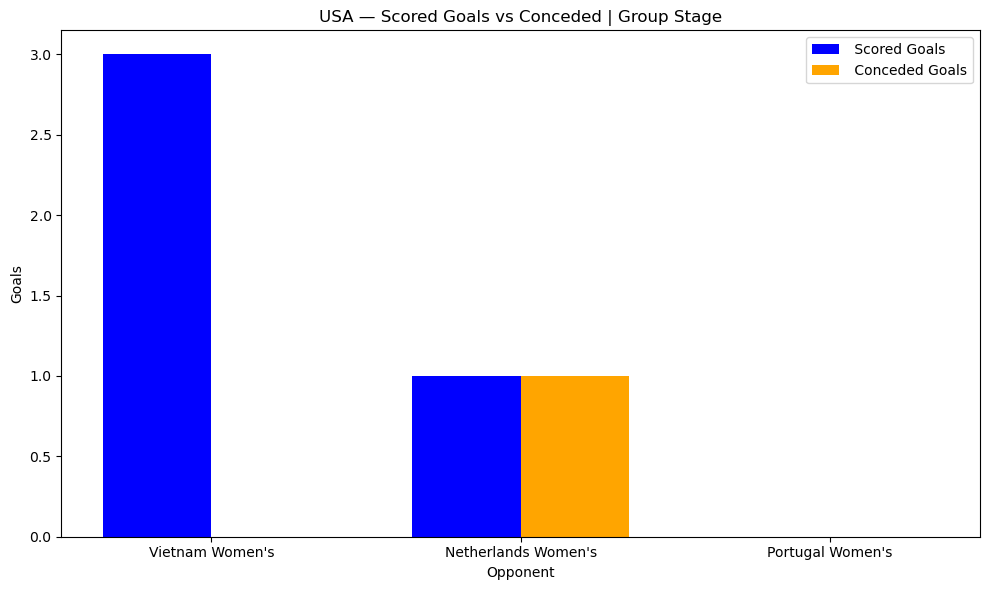

In [48]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "United States Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("USA — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

USA won one game by scoring 3 goals agaist Vietnam. <br>
Tied two games by scoring one goal against the Netherlands and conceding one in the same game. <br>
As for the second game, neither team scored any goals.

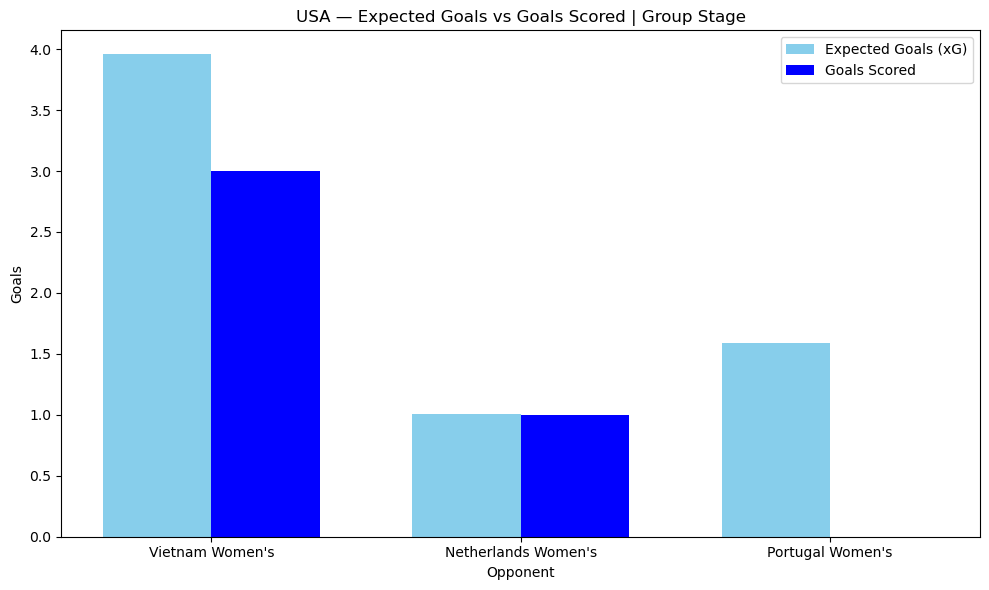

In [50]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "United States Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("USA — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

The United States consistently scored below expectations in its three group-stage matches.

# Analysis USA-POR

In [53]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "United States Women's") &
        (womens_world_cup_stats["opponent"] == "Portugal Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Portugal Women's") &
        (womens_world_cup_stats["opponent"] == "United States Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "USA": [
        match.loc[
            match["team"] == "United States Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Portugal": [
        match.loc[
            match["team"] == "Portugal Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["USA", "Portugal"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["USA", "Portugal"]
].round(1)


# Display table

comparison

,Metric,USA,Portugal
0,Goals,0.0,0.0
1,xG,1.6,0.3
2,Goals Minus xG,-1.6,-0.3
3,Shots,17.0,6.0
4,Shots on Target,5.0,0.0
5,Saves,0.0,5.0
6,Possession %,53.6,46.4
7,Pass Accuracy %,65.5,69.8
8,Progressive Passes,98.0,104.0
9,Progressive Carries,16.0,7.0


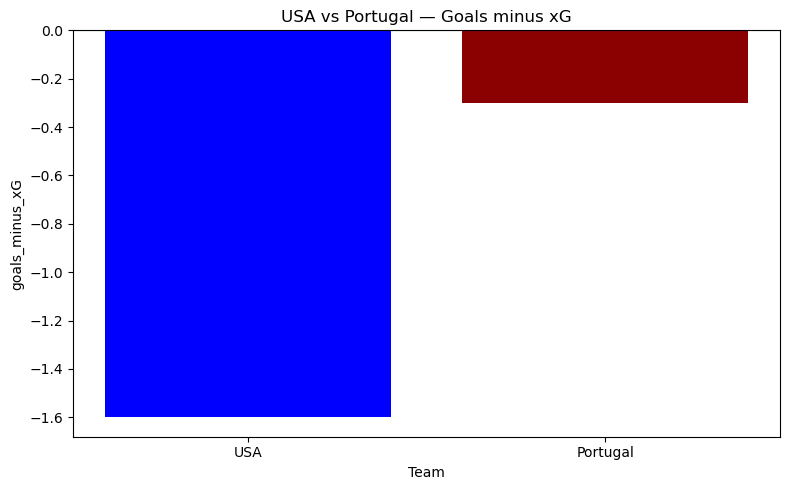

In [54]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "United States Women's") &
        (womens_world_cup_stats["opponent"] == "Portugal Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Portugal Women's") &
        (womens_world_cup_stats["opponent"] == "United States Women's")
    )
].copy()


teams = ["USA", "Portugal"]

goals_minus_xG = [
    match.loc[match["team"] == "United States Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Portugal Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["blue", "darkred"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("USA vs Portugal — Goals minus xG")

plt.tight_layout()
plt.show()

Neither team reached their expected goals, especially the U.S., which had an xG of 1.5 but failed to score.

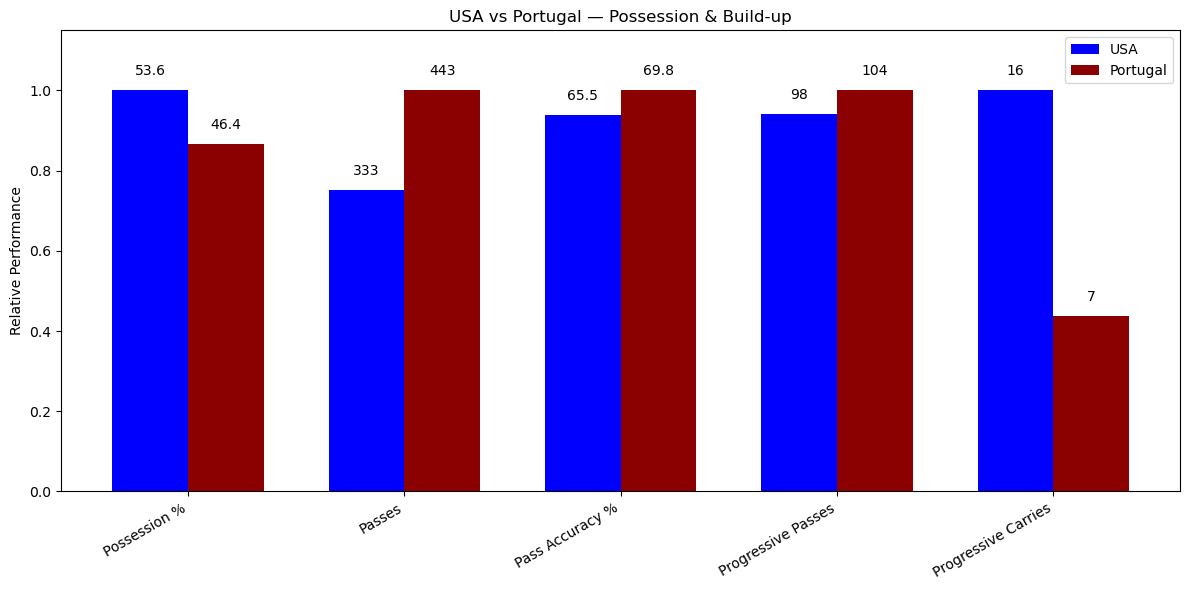

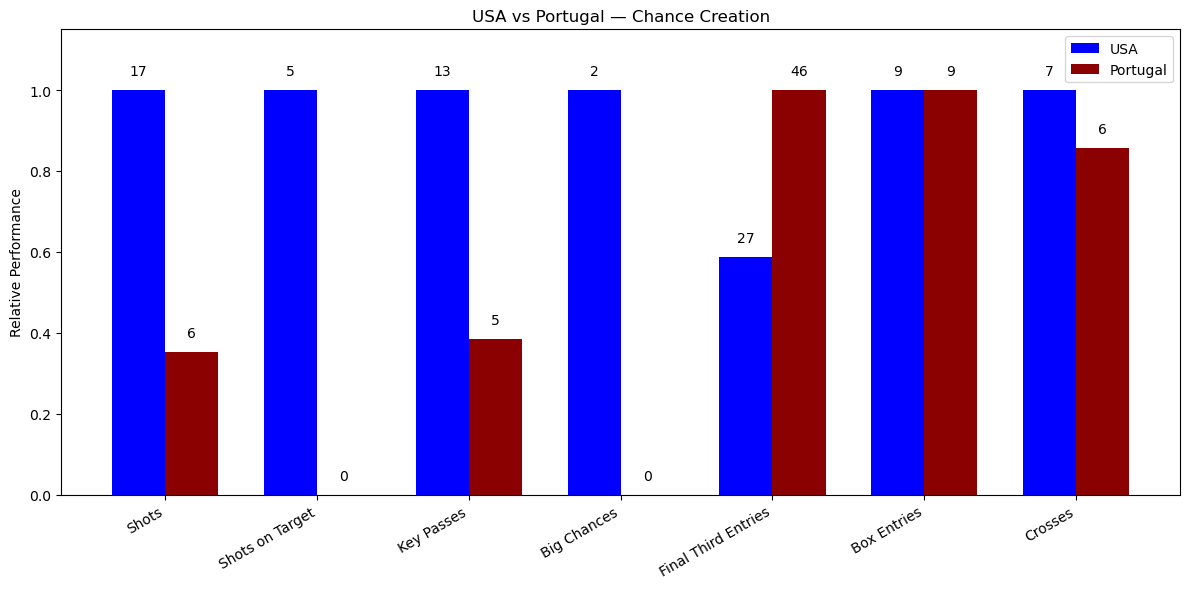

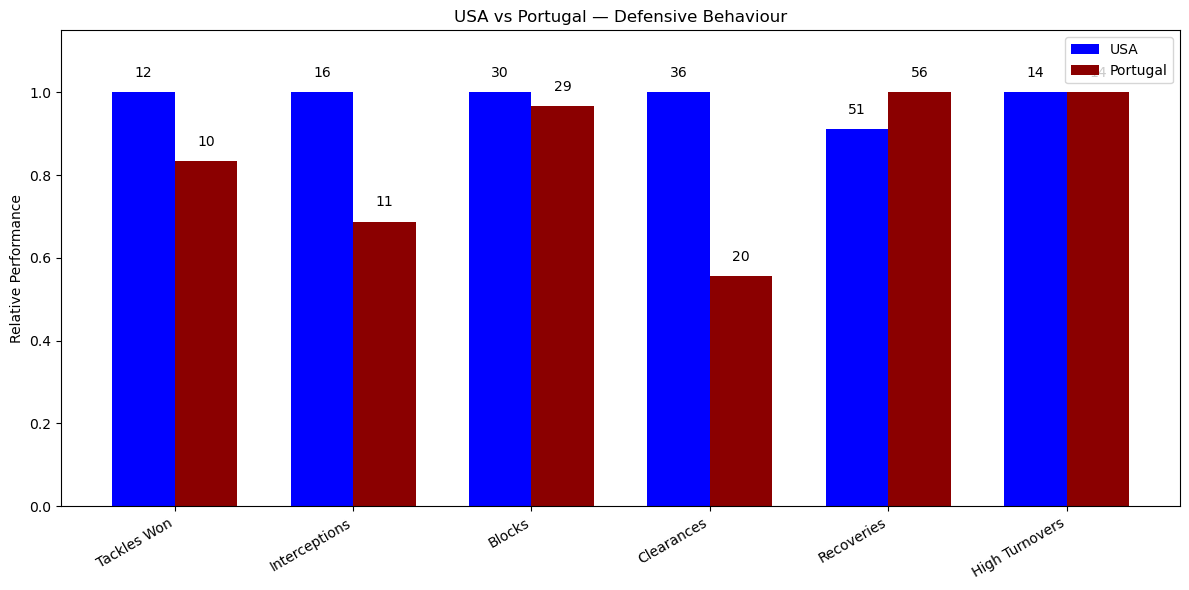

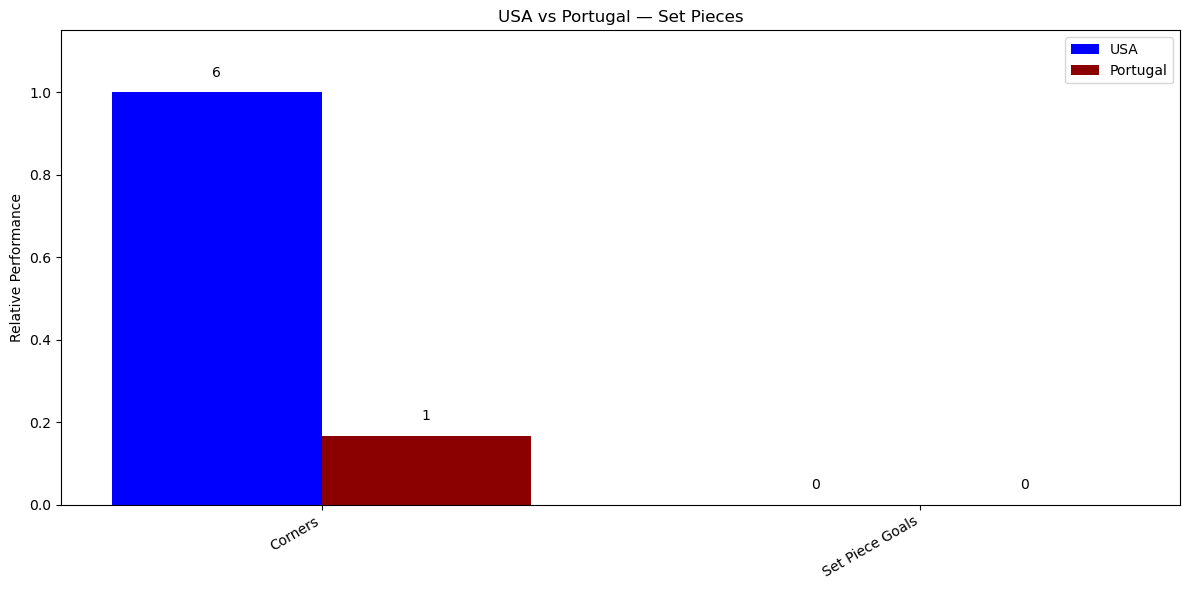

In [56]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "United States Women's") &
        (womens_world_cup_stats["opponent"] == "Portugal Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Portugal Women's") &
        (womens_world_cup_stats["opponent"] == "United States Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "USA": "United States Women's",
    "Portugal": "Portugal Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    usa_values = np.array([
        match.loc[
            match["team"] == team_names["USA"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    por_values = np.array([
        match.loc[
            match["team"] == team_names["Portugal"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(usa_values, por_values)

    # Normalize
    usa_normalized = np.divide(
        usa_values,
        max_values,
        out=np.zeros_like(usa_values),
        where=max_values != 0
    )

    por_normalized = np.divide(
        por_values,
        max_values,
        out=np.zeros_like(por_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_usa = plt.bar(
        x - width / 2,
        usa_normalized,
        width,
        label="USA",
        color="blue"
    )

    bars_por = plt.bar(
        x + width / 2,
        por_normalized,
        width,
        label="Portugal",
        color="darkred"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_usa, usa_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_por, por_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"USA vs Portugal — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of USA-POR

In terms of possession, the game was fairly even. Both teams posted very similar numbers, although Portugal had higher figures in some metrics. Looking at the attacking statistics, Portugal clearly struggled to finish, despite having a greater presence in the final third.
The U.S. had more scoring opportunities and more shots, including more on target. The team’s defensive capabilities also stood out. 

# Analysis USA-VIE

In [60]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "United States Women's") &
        (womens_world_cup_stats["opponent"] == "Vietnam Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Vietnam Women's") &
        (womens_world_cup_stats["opponent"] == "United States Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "USA": [
        match.loc[
            match["team"] == "United States Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Vietnam": [
        match.loc[
            match["team"] == "Vietnam Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["USA", "Vietnam"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["USA", "Vietnam"]
].round(1)


# Display table

comparison

,Metric,USA,Vietnam
0,Goals,3.0,0.0
1,xG,4.0,0.0
2,Goals Minus xG,-1.0,0.0
3,Shots,29.0,0.0
4,Shots on Target,6.0,0.0
5,Saves,0.0,3.0
6,Possession %,71.4,28.6
7,Pass Accuracy %,74.8,52.7
8,Progressive Passes,133.0,73.0
9,Progressive Carries,31.0,5.0


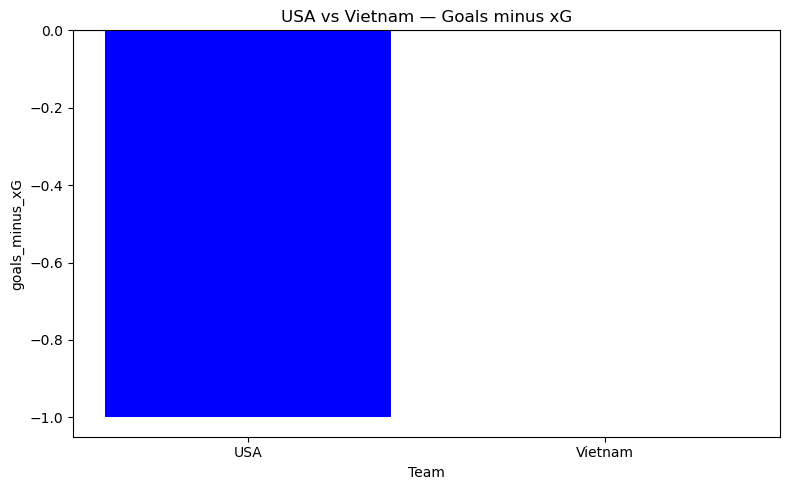

In [61]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "United States Women's") &
        (womens_world_cup_stats["opponent"] == "Vietnam Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Vietnam Women's") &
        (womens_world_cup_stats["opponent"] == "United States Women's")
    )
].copy()


teams = ["USA", "Vietnam"]

goals_minus_xG = [
    match.loc[match["team"] == "United States Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Vietnam Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["blue", "silver"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("USA vs Vietnam — Goals minus xG")

plt.tight_layout()
plt.show()

The United States fell short of xG, scoring 3 goals against an xG of 4.0. Vietnam, on the other hand, performed exactly as predicted.

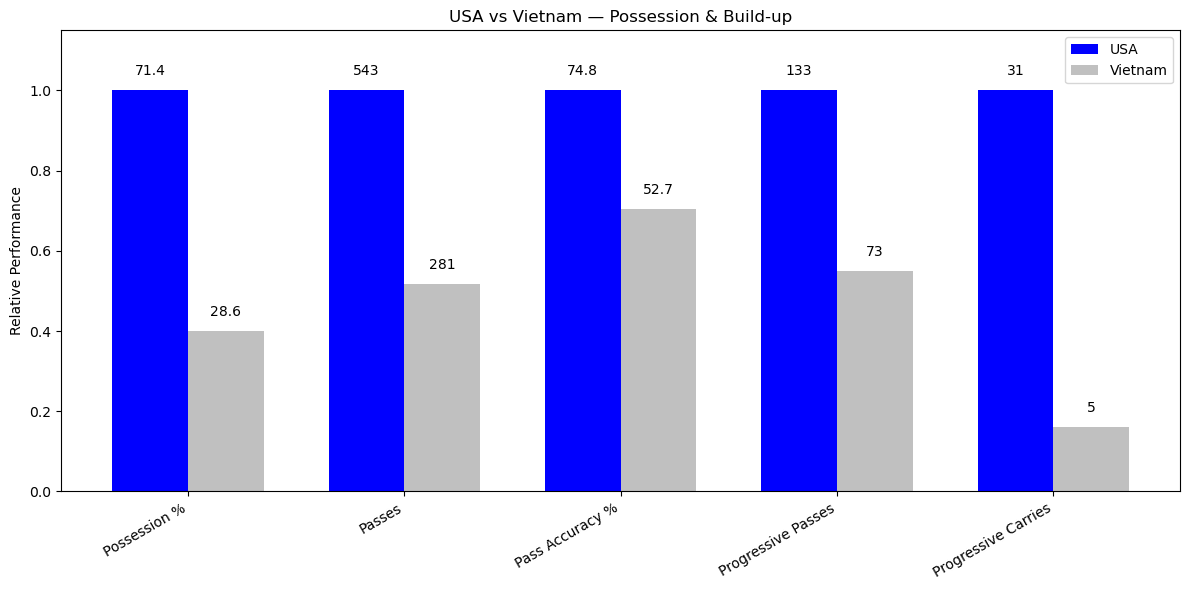

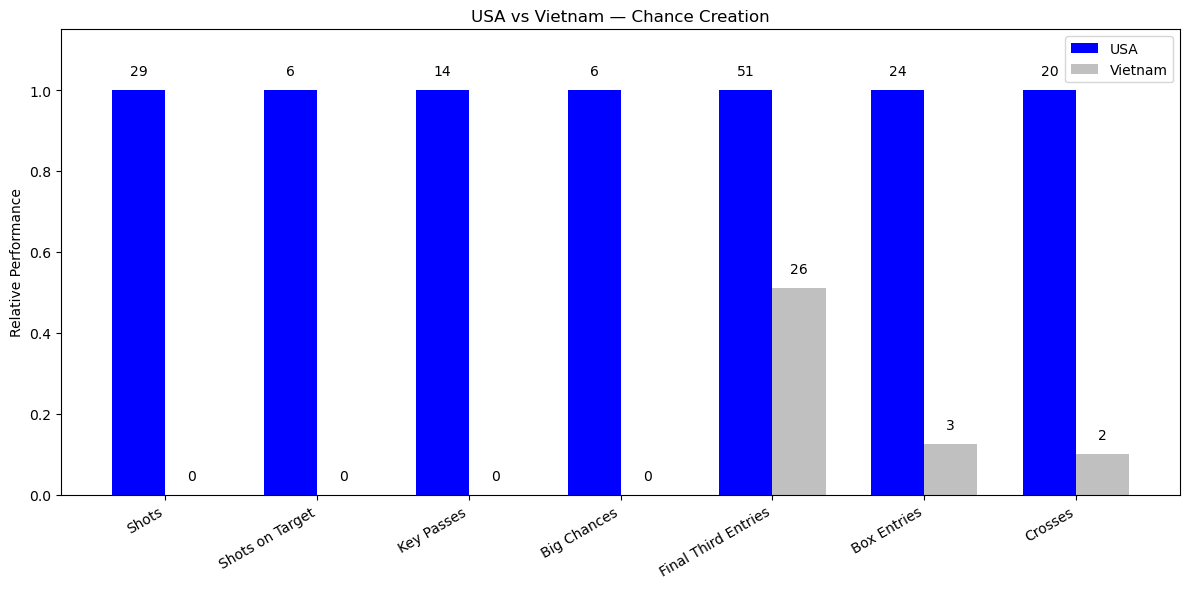

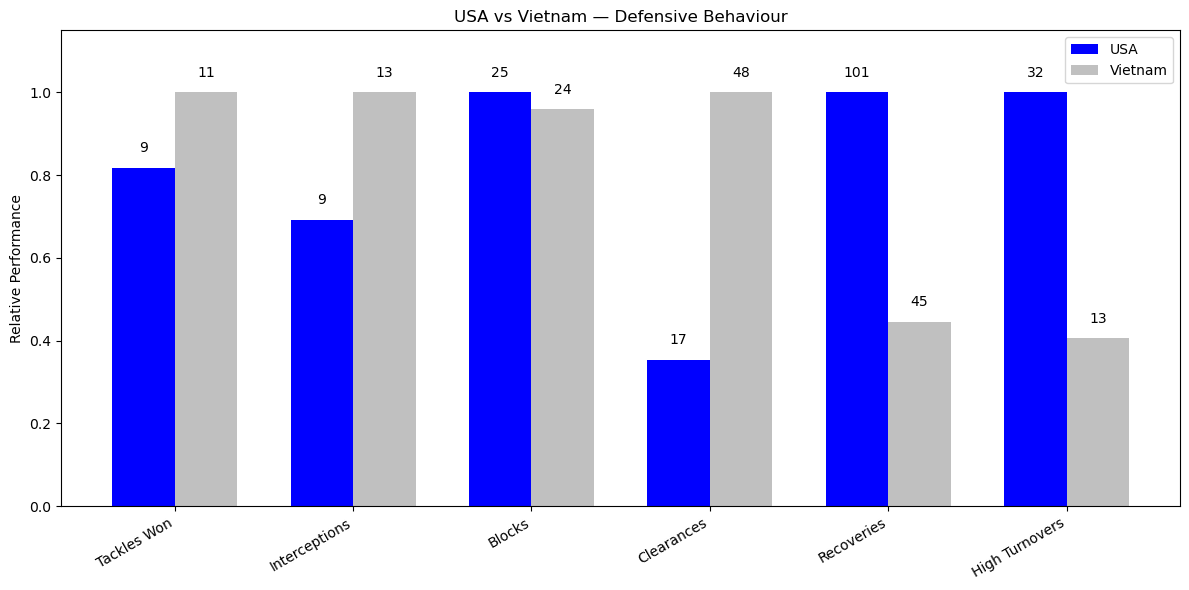

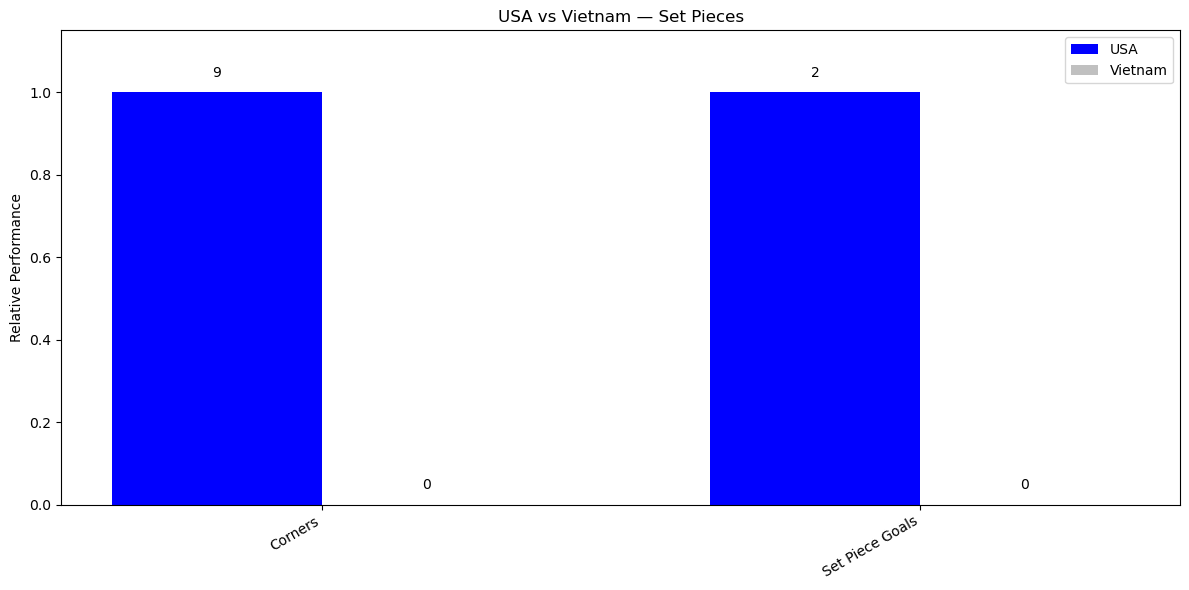

In [63]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "United States Women's") &
        (womens_world_cup_stats["opponent"] == "Vietnam Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Vietnam Women's") &
        (womens_world_cup_stats["opponent"] == "United States Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "USA": "United States Women's",
    "Vietnam": "Vietnam Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    usa_values = np.array([
        match.loc[
            match["team"] == team_names["USA"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    vie_values = np.array([
        match.loc[
            match["team"] == team_names["Vietnam"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(usa_values, vie_values)

    # Normalize
    usa_normalized = np.divide(
        usa_values,
        max_values,
        out=np.zeros_like(usa_values),
        where=max_values != 0
    )

    vie_normalized = np.divide(
        vie_values,
        max_values,
        out=np.zeros_like(vie_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_usa = plt.bar(
        x - width / 2,
        usa_normalized,
        width,
        label="USA",
        color="blue"
    )

    bars_vie = plt.bar(
        x + width / 2,
        vie_normalized,
        width,
        label="Vietnam",
        color="silver"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_usa, usa_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_vie, vie_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"USA vs Vietnam — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of USA-VIE

The U.S. clearly dominated the game, with 71.4% possession, 29 shots, 24 entries into the box, and 4.0 xG, while Vietnam did not register a single shot. Although Vietnam had more tackles, interceptions, and clearances, these numbers primarily reflect the time spent defending. The 3–0 result is, therefore, quite representative of the U.S.’s superiority.

# Analysis Portugal's Group Stage games

In [67]:
team = "Portugal Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
20,3893797,Netherlands Women's,Portugal Women's,Group
21,3893797,Portugal Women's,Netherlands Women's,Group
46,3893810,Portugal Women's,Vietnam Women's,Group
47,3893810,Vietnam Women's,Portugal Women's,Group
78,3893826,Portugal Women's,United States Women's,Group
79,3893826,United States Women's,Portugal Women's,Group


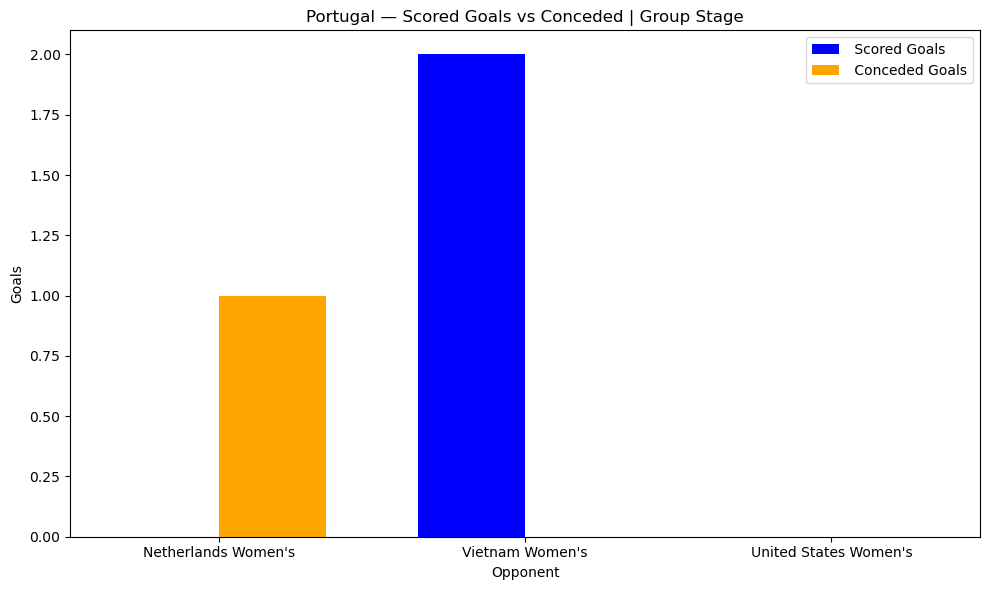

In [68]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Portugal Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Portugal — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

According to the chart, Portugal won one game (against Vietnam), lost one game (against the Netherlands), and tied with the United States. 

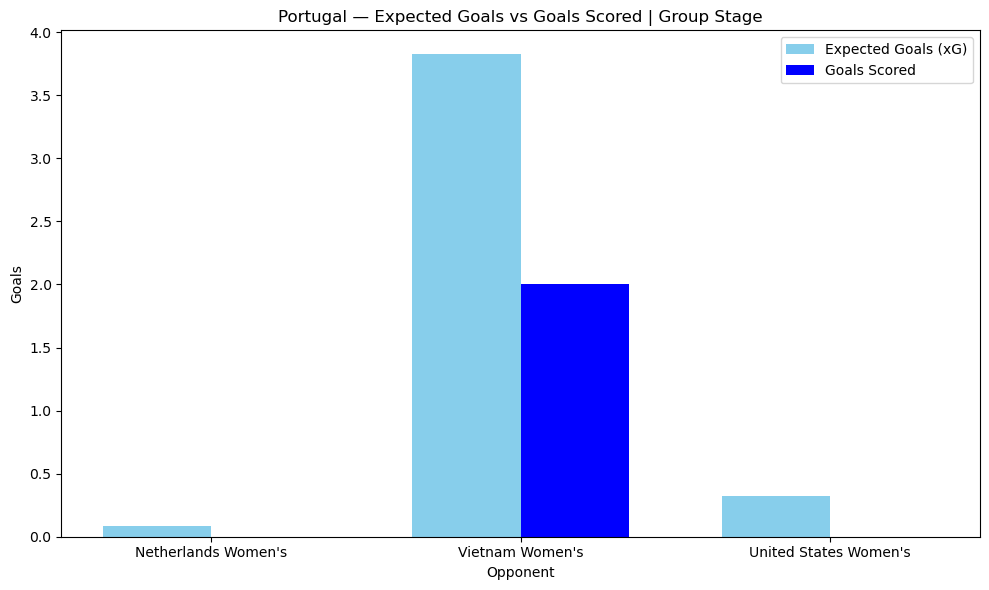

In [70]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Portugal Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Portugal — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Portugal has consistently posted xG figures below the opponent's in the matches against the three teams it has faced. What stands out most is the discrepancy compared to the xG for the game against Vietnam. 

# Analysis POR-VIE

In [73]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Portugal Women's") &
        (womens_world_cup_stats["opponent"] == "Vietnam Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Vietnam Women's") &
        (womens_world_cup_stats["opponent"] == "Portugal Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Portugal": [
        match.loc[
            match["team"] == "Portugal Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Vietnam": [
        match.loc[
            match["team"] == "Vietnam Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Portugal", "Vietnam"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Portugal", "Vietnam"]
].round(1)


# Display table

comparison

,Metric,Portugal,Vietnam
0,Goals,2.0,0.0
1,xG,3.8,0.2
2,Goals Minus xG,-1.8,-0.2
3,Shots,29.0,5.0
4,Shots on Target,9.0,1.0
5,Saves,1.0,7.0
6,Possession %,72.7,27.3
7,Pass Accuracy %,82.6,58.5
8,Progressive Passes,140.0,84.0
9,Progressive Carries,19.0,7.0


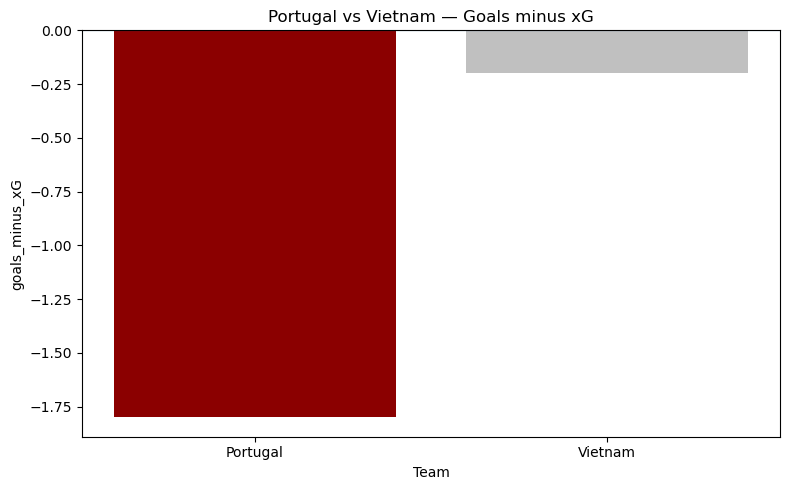

In [74]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Portugal Women's") &
        (womens_world_cup_stats["opponent"] == "Vietnam Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Vietnam Women's") &
        (womens_world_cup_stats["opponent"] == "Portugal Women's")
    )
].copy()


teams = ["Portugal", "Vietnam"]

goals_minus_xG = [
    match.loc[match["team"] == "Portugal Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Vietnam Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["darkred", "silver"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Portugal vs Vietnam — Goals minus xG")

plt.tight_layout()
plt.show()

Neither team exceeded their xG, but Portugal had the largest discrepancy, thus revealing a lack of finishing or efficiency. 

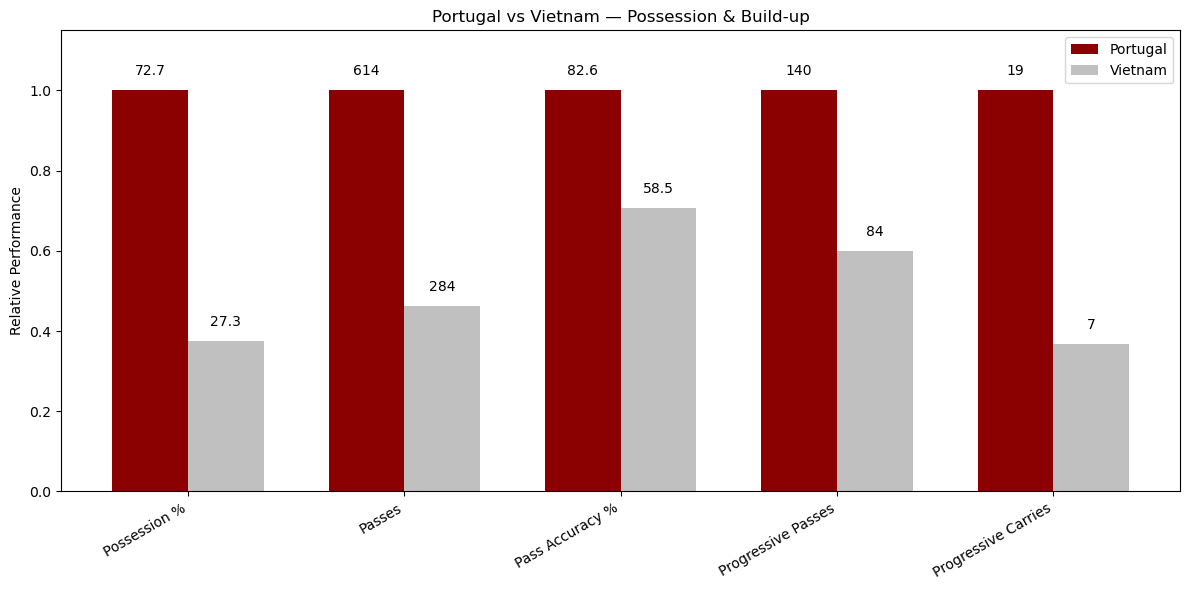

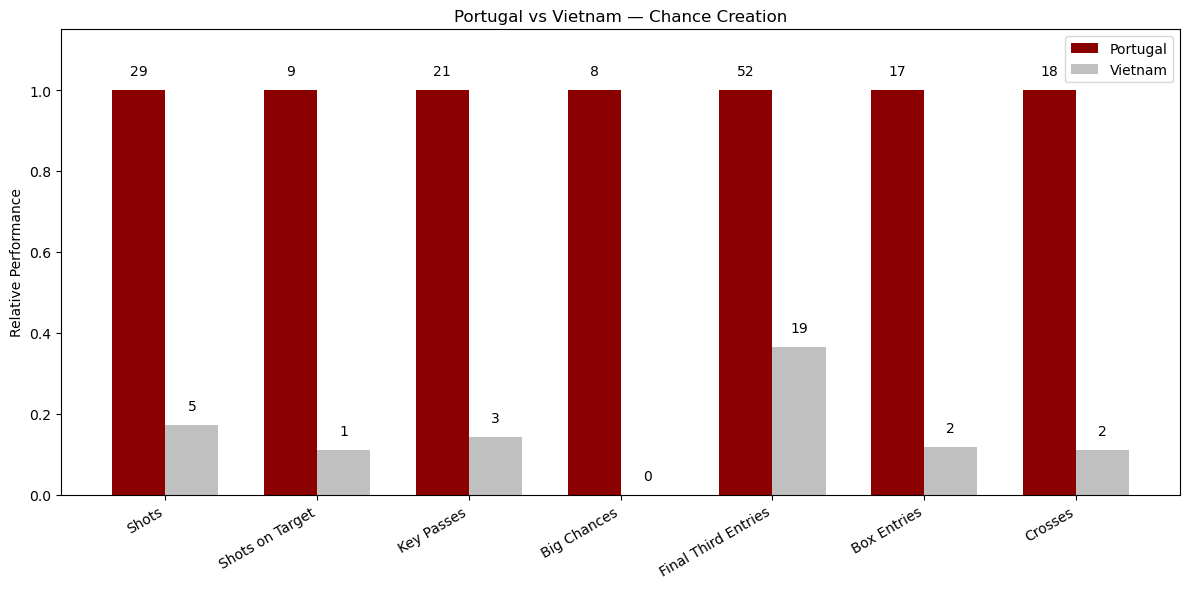

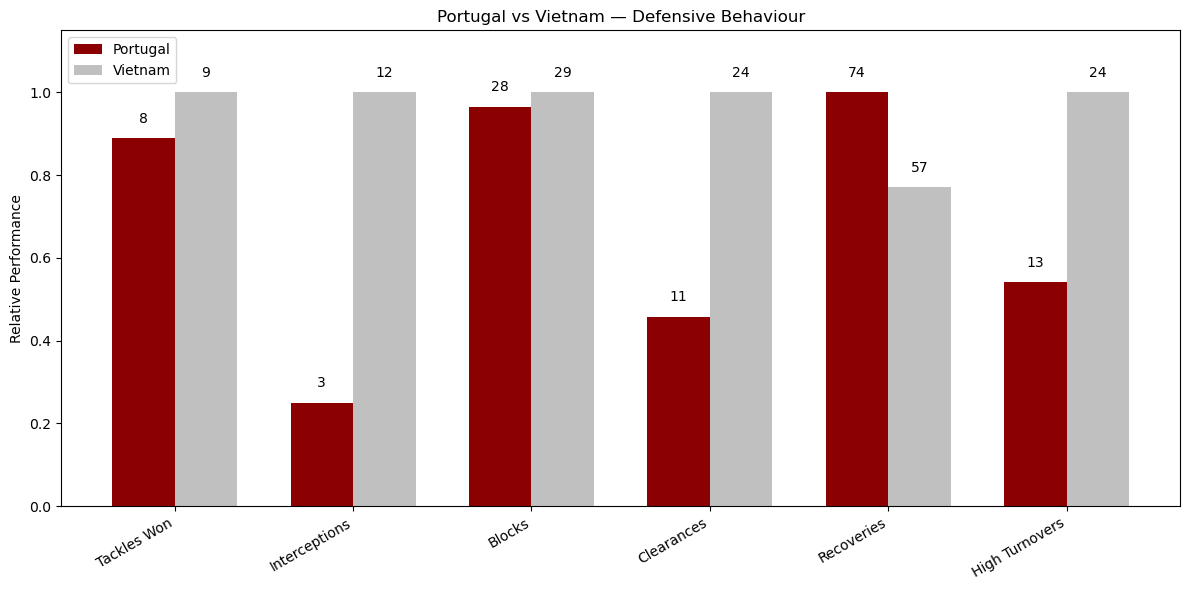

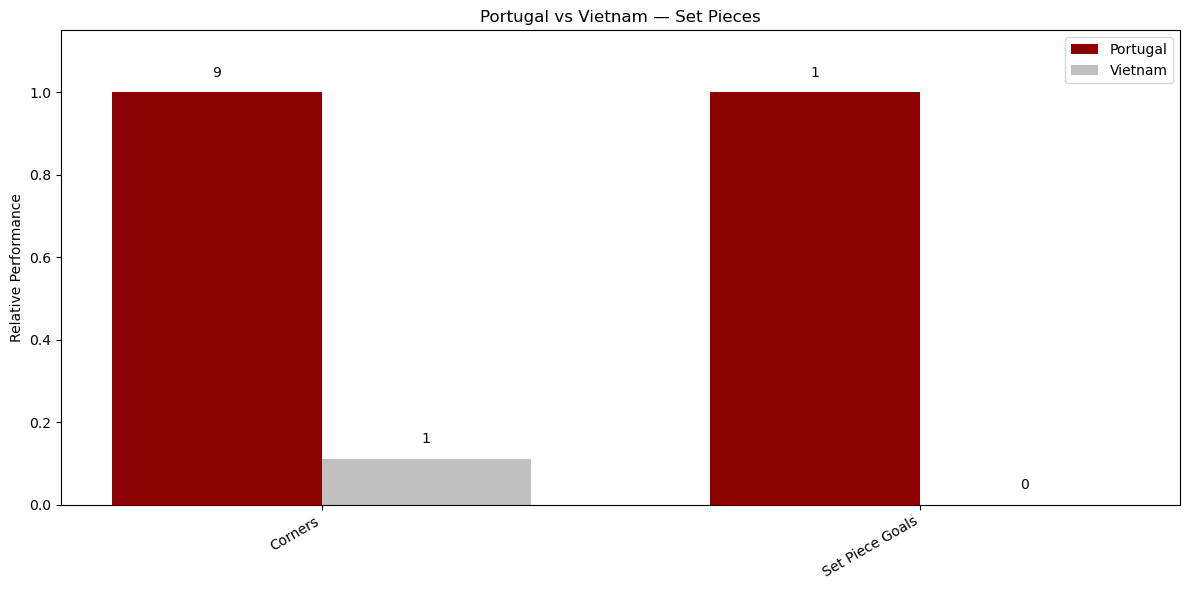

In [76]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Portugal Women's") &
        (womens_world_cup_stats["opponent"] == "Vietnam Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Vietnam Women's") &
        (womens_world_cup_stats["opponent"] == "Portugal Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Portugal": "Portugal Women's",
    "Vietnam": "Vietnam Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    por_values = np.array([
        match.loc[
            match["team"] == team_names["Portugal"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    vie_values = np.array([
        match.loc[
            match["team"] == team_names["Vietnam"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(por_values, vie_values)

    # Normalize
    por_normalized = np.divide(
        por_values,
        max_values,
        out=np.zeros_like(por_values),
        where=max_values != 0
    )

    vie_normalized = np.divide(
        vie_values,
        max_values,
        out=np.zeros_like(vie_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_por = plt.bar(
        x - width / 2,
        por_normalized,
        width,
        label="Portugal",
        color="darkred"
    )

    bars_vie = plt.bar(
        x + width / 2,
        vie_normalized,
        width,
        label="Vietnam",
        color="silver"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_por, por_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_vie, vie_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Portugal vs Vietnam — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion POR-VIE

As we can see from the charts, Portugal completely dominated the game in terms of possession and attack. However, it’s worth noting the team’s defensive capabilities in the face of Portugal’s constant attack.
It should be added that, despite Portugal’s clear dominance, there was some inconsistency in their finishing: *29 shots, only **9 were on target**, and **2 of them resulted in goals**.

# Final conclusion group E

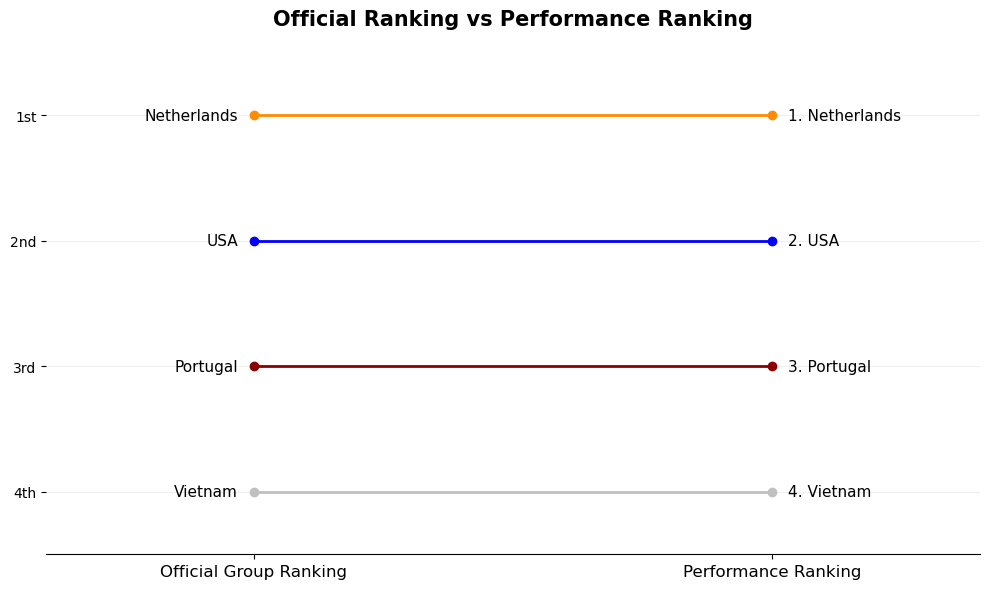

In [80]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# DATA
# ==========================================

ranking = pd.DataFrame({
    "team": ["Netherlands", "USA", "Portugal", "Vietnam"],
    "official_rank": [1, 2, 3, 4],
    "performance_rank": [1, 2, 3, 4]
})

# ==========================================
# COLORS
# ==========================================

team_colors = {
    "Netherlands": "darkorange",
    "USA": "blue",
    "Portugal": "darkred",
    "Vietnam": "silver"
}

# ==========================================
# PLOT
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in ranking.iterrows():

    ax.plot(
        [0, 1],
        [row["official_rank"], row["performance_rank"]],
        marker="o",
        linewidth=2,
        color=team_colors[row["team"]]
    )

    # Official ranking
    ax.text(
        -0.03,
        row["official_rank"],
        row["team"],
        ha="right",
        va="center",
        fontsize=11
    )

    # Performance ranking
    ax.text(
        1.03,
        row["performance_rank"],
        f'{row["performance_rank"]}. {row["team"]}',
        ha="left",
        va="center",
        fontsize=11
    )

# ==========================================
# FORMATTING
# ==========================================

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(4.5, 0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Official Group Ranking",
    "Performance Ranking"
], fontsize=12)

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1st", "2nd", "3rd", "4th"])

ax.set_title(
    "Official Ranking vs Performance Ranking",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

I’m sticking with the same rankings as those projected for the tournament. I believe the Netherlands stood out the most, despite drawing one game, as they were more productive relative to xG and consistently dominated their matches. 
I’d also like to highlight Portugal for holding its own against visibly more skilled teams, suffering only a one-goal loss and earning a draw against the No. 1 team in the FIFA rankings (the United States). 
The United States maintained consistent performance throughout the tournament, playing a very attacking style of football. 
I give credit to Vietnam’s performance, as they faced three teams still ranked in the FIFA top 20 and managed to put up a very impressive defensive effort.